# Conditional Covariate Evolution Under SSP Scenarios

## Motivation

In our scenario analysis (`laos_climate_change_curve_scenarios.ipynb`), we project disaster damage under different SSP CO$_2$ pathways. It is known that changes in CO2 path also affect the other coavriates of the model; for example, higher CO$_2$ concentrations lead to warmer ocean temperatures and altered precipitation patterns. Fortunately, our multivariate Bayesian ETS model (from `00b_time_series_forecasting_lao.ipynb`) **jointly estimated** all these variables, learning the innovation covariance between them.

In this notebook, we use the **multivariate Gaussian conditional distribution** to propagate CO$_2$ scenario deviations to the other climate covariates.

In [1]:
import sys
from pyprojroot import here
sys.path.insert(0, str(here()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from sklearn.preprocessing import StandardScaler

from laos_gggi.data_functions import process_ipcc_scenarios, load_all_data

np.set_printoptions(precision=4, suppress=True)

## 1. Load the ETS posterior innovation covariance

The Bayesian ETS model was fit on 5 variables: `real_gdp`, `Population`, `precip`, `co2`, `Temp`. The model estimated a **dense innovation covariance matrix** $\Sigma$ that captures how shocks to one variable are correlated with shocks to others.

This covariance was learned in **log-standardized space** (the data was log-transformed then standardized with zero mean and unit variance before fitting).

In [2]:
# Load the ETS posterior
ets_idata = az.from_netcdf(here("notebooks/final_paper/idata/time_series_laos.idata"))

# Extract the innovation covariance matrix
state_cov = ets_idata.posterior['state_cov']

# Variable ordering
var_names = [s.replace('_innovation', '') for s in state_cov.coords['shock'].values]
print("Variable ordering:", var_names)
print(f"\nShape: {state_cov.shape} (chains x draws x variables x variables)")

Variable ordering: ['real_gdp', 'Population', 'precip', 'co2', 'Temp']

Shape: (6, 1000, 5, 5) (chains x draws x variables x variables)


## 2. Inspect the innovation covariance

The innovation covariance matrix $\Sigma$ tells us how unexpected changes (innovations) in one variable relate to unexpected changes in others. We focus on the **correlation matrix** for interpretability.

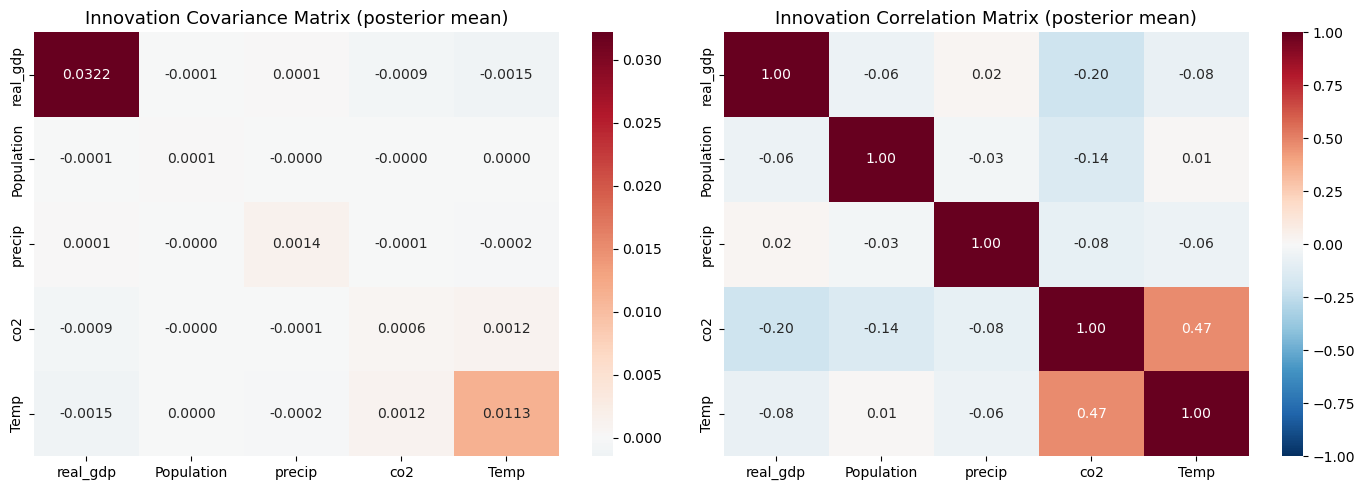

In [3]:
# Posterior mean of the innovation covariance
cov_mean = state_cov.mean(dim=['chain', 'draw']).values

# Convert to correlation matrix
std = np.sqrt(np.diag(cov_mean))
corr_mean = cov_mean / np.outer(std, std)

# Display as heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cov_mean, annot=True, fmt='.4f', xticklabels=var_names, yticklabels=var_names,
            cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Innovation Covariance Matrix (posterior mean)', fontsize=13)

sns.heatmap(corr_mean, annot=True, fmt='.2f', xticklabels=var_names, yticklabels=var_names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Innovation Correlation Matrix (posterior mean)', fontsize=13)

plt.tight_layout()
plt.show()

### Key observations

- **CO$_2$ $\leftrightarrow$ Temp: $r = 0.47$** -- this is the strongest cross-correlation. When CO$_2$ experiences a positive innovation (rises faster than expected), ocean temperature tends to rise too. This is physically intuitive: more greenhouse gases $\to$ more trapped heat.
- **CO$_2$ $\leftrightarrow$ precip: $r = -0.08$** -- very weak negative correlation. CO$_2$ innovations have little direct linear relationship with precipitation innovations in the data.
- **CO$_2$ $\leftrightarrow$ GDP: $r = -0.20$** -- moderate negative correlation, possibly reflecting that periods of rapid economic growth (more emissions) coincide with different GDP dynamics.

For the scenario analysis, the **CO$_2$ $\to$ Temp** channel is the most important one to capture.

## 3. The multivariate Gaussian conditional distribution

If a random vector $\mathbf{X} = (X_1, X_2)$ follows a multivariate Gaussian distribution:

$$\begin{pmatrix} X_1 \\ X_2 \end{pmatrix} \sim \mathcal{N}\left( \begin{pmatrix} \mu_1 \\ \mu_2 \end{pmatrix}, \begin{pmatrix} \Sigma_{11} & \Sigma_{12} \\ \Sigma_{21} & \Sigma_{22} \end{pmatrix} \right)$$

then the **conditional distribution** of $X_2$ given $X_1 = x_1$ is:

$$X_2 \mid X_1 = x_1 \sim \mathcal{N}\left( \mu_2 + \Sigma_{21} \Sigma_{11}^{-1} (x_1 - \mu_1), \; \Sigma_{22} - \Sigma_{21} \Sigma_{11}^{-1} \Sigma_{12} \right)$$

In our case:
- $X_1$ = CO$_2$ (the variable we fix to SSP values)
- $X_2$ = all other variables (Temp, precip, GDP, Population)
- $\Sigma_{11}$ = Var(CO$_2$) (a scalar)
- $\Sigma_{21}$ = Cov(other variables, CO$_2$) (a vector)

The **conditional mean adjustment** simplifies to:

$$\Delta X_\text{other} = \frac{\text{Cov}(X_\text{other}, \text{CO}_2)}{\text{Var}(\text{CO}_2)} \times (\text{CO}_{2,\text{SSP}} - \text{CO}_{2,\text{baseline}})$$

This is just a **regression coefficient** $\beta = \text{Cov}(X, \text{CO}_2) / \text{Var}(\text{CO}_2)$ applied to the CO$_2$ deviation.

## 4. Compute the conditional regression coefficients

We extract $\beta_j = \text{Cov}(X_j, \text{CO}_2) / \text{Var}(\text{CO}_2)$ for each variable $j$.

**Important:** These coefficients operate in **log-standardized space** (the space in which the ETS model was estimated). To apply them to raw data, we need to transform the CO$_2$ deviations into this space first, then transform the adjustments back.

In [4]:
# Variable indices in the covariance matrix
# Ordering: [real_gdp, Population, precip, co2, Temp]
CO2_IDX = var_names.index('co2')
TEMP_IDX = var_names.index('Temp')
PRECIP_IDX = var_names.index('precip')

print(f"CO2 index: {CO2_IDX}, Temp index: {TEMP_IDX}, Precip index: {PRECIP_IDX}")

# Compute conditional regression coefficients: beta_j = Cov(j, CO2) / Var(CO2)
var_co2 = cov_mean[CO2_IDX, CO2_IDX]

betas = {}
for i, name in enumerate(var_names):
    if i != CO2_IDX:
        betas[name] = cov_mean[i, CO2_IDX] / var_co2

print("\nConditional regression coefficients (in log-standardized space):")
print("beta_j = Cov(j, CO2) / Var(CO2)")
print("-" * 50)
for name, beta in betas.items():
    corr = corr_mean[var_names.index(name), CO2_IDX]
    print(f"  {name:12s}: beta = {beta:+.4f}  (correlation = {corr:+.4f})")

CO2 index: 3, Temp index: 4, Precip index: 2

Conditional regression coefficients (in log-standardized space):
beta_j = Cov(j, CO2) / Var(CO2)
--------------------------------------------------
  real_gdp    : beta = -1.5189  (correlation = -0.2031)
  Population  : beta = -0.0708  (correlation = -0.1406)
  precip      : beta = -0.1288  (correlation = -0.0838)
  Temp        : beta = +2.0870  (correlation = +0.4713)


### Interpretation

- A **positive** $\beta_\text{Temp}$ means: for each unit increase in standardized log-CO$_2$, standardized log-Temp increases by $\beta_\text{Temp}$ units.
- The magnitudes tell us how strongly each variable responds to CO$_2$ deviations.
- We will apply these adjustments to **Temp** and **precip** (the climate variables). We leave GDP and Population at baseline since their correlations with CO$_2$ are small and their causal link to atmospheric CO$_2$ on our forecast horizon is indirect.

## 5. Load SSP scenarios and baseline forecasts

We need the SSP CO$_2$ trajectories and the baseline forecast to compute the CO$_2$ deviation $\Delta\text{CO}_2 = \text{CO}_{2,\text{SSP}} - \text{CO}_{2,\text{baseline}}$.

In [5]:
# Load SSP CO2 concentration scenarios
ipcc_scenarios = process_ipcc_scenarios()
SCENARIOS = list(ipcc_scenarios.columns)
print("Scenarios:", SCENARIOS)

# Load baseline forecasts
baseline_atmos = pd.read_csv(here('data/CRIforecast.csv'))
baseline_lao = pd.read_csv(here('data/climate_forecast_lao.csv'))

print(f"\nBaseline atmospheric forecast columns: {list(baseline_atmos.columns)}")
print(f"Baseline Laos forecast columns: {list(baseline_lao.columns)}")
print(f"\nBaseline CO2 range: {baseline_atmos['co2'].min():.1f} - {baseline_atmos['co2'].max():.1f} ppm")

Loading cached IPCC SSP CO2 concentration data


Scenarios: ['SSP3-70', 'SSP1-19', 'SSP1-26', 'SSP2-45', 'SSP5-85']

Baseline atmospheric forecast columns: ['time', 'real_gdp', 'Population', 'precip', 'co2', 'Temp', 'gdp_per_cap', 'dev_ocean_temp', 'precip_deviation']
Baseline Laos forecast columns: ['time', 'real_gdp', 'Population', 'precip', 'co2', 'Temp', 'gdp_per_cap', 'dev_ocean_temp', 'precip_deviation']

Baseline CO2 range: 338.8 - 596.8 ppm


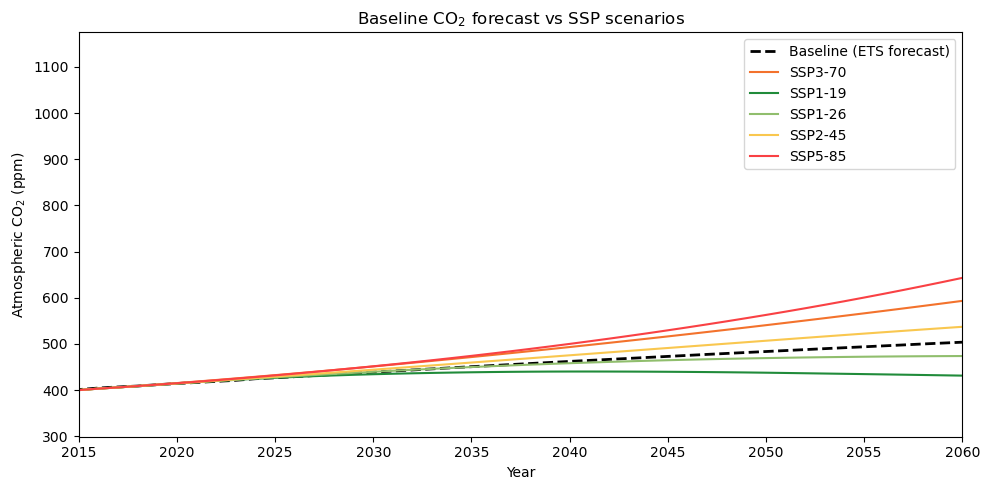

In [6]:
# Parse years for plotting
baseline_atmos['year'] = pd.to_datetime(baseline_atmos['time']).dt.year

# Visualize baseline CO2 vs SSP scenarios
scenario_colors = {
    'SSP1-19': '#208b3a', 'SSP1-26': '#90be6d', 'SSP2-45': '#f9c74f',
    'SSP3-70': '#f3722c', 'SSP5-85': '#f94144',
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(baseline_atmos['year'], baseline_atmos['co2'], 'k--', lw=2, label='Baseline (ETS forecast)')
for scenario in SCENARIOS:
    ax.plot(ipcc_scenarios.index, ipcc_scenarios[scenario],
            color=scenario_colors[scenario], label=scenario)
ax.set_xlabel('Year')
ax.set_ylabel('Atmospheric CO$_2$ (ppm)')
ax.set_title('Baseline CO$_2$ forecast vs SSP scenarios')
ax.legend()
ax.set_xlim(2015, 2060)
plt.tight_layout()
plt.show()

## 6. Apply conditional adjustments

The regression coefficients $\beta$ operate in **log-standardized space**. To apply them to raw ppm values, we need to:

1. Transform the baseline and SSP CO$_2$ values to log-standardized space: $z = (\log(x) - \mu) / \sigma$
2. Compute the deviation $\Delta z = z_\text{SSP} - z_\text{baseline}$
3. Compute adjustments for other variables: $\Delta z_j = \beta_j \cdot \Delta z_\text{CO2}$
4. Apply to baseline values in log-standardized space and transform back

We first need to reconstruct the `StandardScaler` used in the ETS notebook.

In [7]:
# Reconstruct the exact scaler from the ETS notebook
# (same data pipeline as 00b_time_series_forecasting_lao.ipynb)
data = load_all_data()
df_raw = data['df_time_series'][['co2', 'Temp']]
iso_df = data['df_panel'].loc['LAO'][['real_gdp', 'Population', 'precip']]
df_merged = pd.merge(iso_df, df_raw, left_index=True, right_index=True, how='right').query('year > 1979')
for col in ['real_gdp', 'Population']:
    df_merged[col] = df_merged[col] / 1e6

scaler = StandardScaler()
scaler.fit(df_merged.map(np.log))

# Show scaler parameters for CO2
col_idx = list(df_merged.columns)
co2_col_idx = col_idx.index('co2')
temp_col_idx = col_idx.index('Temp')
precip_col_idx = col_idx.index('precip')

print("Scaler parameters (log space):")
for name, mu, sigma in zip(col_idx, scaler.mean_, scaler.scale_):
    print(f"  {name:12s}: mean = {mu:.4f}, std = {sigma:.4f}")

Scaler parameters (log space):
  real_gdp    : mean = 8.2011, std = 1.0981
  Population  : mean = 1.6738, std = 0.2473
  precip      : mean = 7.5314, std = 0.0975
  co2         : mean = 5.9291, std = 0.0660
  Temp        : mean = 5.0718, std = 0.0432


In [8]:
def to_log_std(x, col_idx):
    """Transform raw value to log-standardized space."""
    return (np.log(x) - scaler.mean_[col_idx]) / scaler.scale_[col_idx]

def from_log_std(z, col_idx):
    """Transform from log-standardized space back to raw."""
    return np.exp(z * scaler.scale_[col_idx] + scaler.mean_[col_idx])

# Build scenario-adjusted forecasts
scenario_forecasts = {}

# Parse years from the time column (may be date strings like '1980-01-01' or integers)
baseline_atmos['year'] = pd.to_datetime(baseline_atmos['time']).dt.year

for scenario in SCENARIOS:
    # Start with copies of baseline forecasts
    atmos = baseline_atmos.copy()
    lao = baseline_lao.copy()
    
    for i, row in atmos.iterrows():
        yr = row['year']
        if yr not in ipcc_scenarios.index:
            continue
        
        # CO2 values
        co2_baseline = row['co2']
        co2_ssp = ipcc_scenarios.loc[yr, scenario]
        
        # Compute delta in log-standardized space
        z_baseline = to_log_std(co2_baseline, co2_col_idx)
        z_ssp = to_log_std(co2_ssp, co2_col_idx)
        delta_z_co2 = z_ssp - z_baseline
        
        # Replace CO2 with SSP value
        atmos.loc[i, 'co2'] = co2_ssp
        
        # Adjust ocean temperature (dev_ocean_temp in the forecast)
        temp_adjustment_z = betas['Temp'] * delta_z_co2
        temp_adjustment_raw = temp_adjustment_z * scaler.scale_[temp_col_idx] * np.exp(scaler.mean_[temp_col_idx])
        atmos.loc[i, 'dev_ocean_temp'] = row['dev_ocean_temp'] + temp_adjustment_raw
        
        # Adjust precipitation deviation
        precip_adjustment_z = betas['precip'] * delta_z_co2
        precip_adjustment_raw = precip_adjustment_z * scaler.scale_[precip_col_idx] * np.exp(scaler.mean_[precip_col_idx])
        atmos.loc[i, 'precip_deviation'] = row['precip_deviation'] + precip_adjustment_raw
    
    scenario_forecasts[scenario] = {'atmos': atmos, 'lao': lao}

print("Computed scenario-adjusted forecasts for all SSP scenarios.")

Computed scenario-adjusted forecasts for all SSP scenarios.


## 7. Visualize the adjusted covariates

Let's compare the baseline forecast with the scenario-adjusted trajectories for the climate covariates.

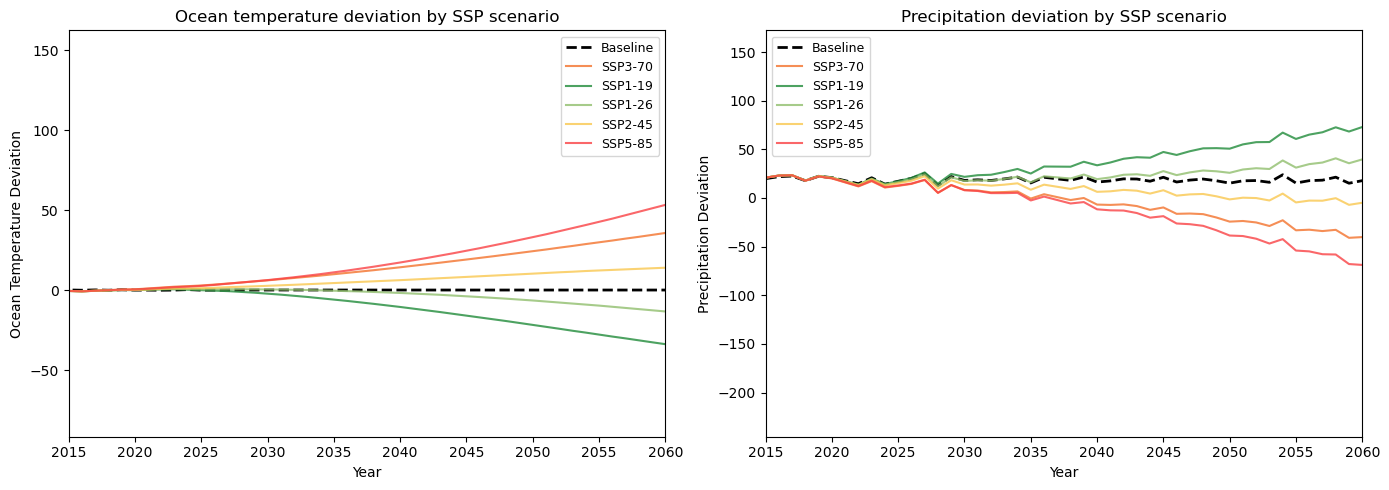

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ocean temperature deviation
ax = axes[0]
ax.plot(baseline_atmos['year'], baseline_atmos['dev_ocean_temp'], 'k--', lw=2, label='Baseline')
for scenario in SCENARIOS:
    atmos = scenario_forecasts[scenario]['atmos']
    ax.plot(atmos['year'], atmos['dev_ocean_temp'],
            color=scenario_colors[scenario], label=scenario, alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Ocean Temperature Deviation')
ax.set_title('Ocean temperature deviation by SSP scenario')
ax.legend(fontsize=9)
ax.set_xlim(2015, 2060)

# Precipitation deviation
ax = axes[1]
ax.plot(baseline_atmos['year'], baseline_atmos['precip_deviation'], 'k--', lw=2, label='Baseline')
for scenario in SCENARIOS:
    atmos = scenario_forecasts[scenario]['atmos']
    ax.plot(atmos['year'], atmos['precip_deviation'],
            color=scenario_colors[scenario], label=scenario, alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Precipitation Deviation')
ax.set_title('Precipitation deviation by SSP scenario')
ax.legend(fontsize=9)
ax.set_xlim(2015, 2060)

plt.tight_layout()
plt.show()

In [10]:
# Summary table: adjustments at year 2050
yr = 2050
print(f"Covariate adjustments at year {yr} relative to baseline:")
print(f"{'Scenario':>10s}  {'CO2 (ppm)':>12s}  {'Temp dev adj':>14s}  {'Precip dev adj':>16s}")
print("-" * 60)

baseline_row = baseline_atmos[baseline_atmos['year'] == yr].iloc[0]
for scenario in SCENARIOS:
    atmos = scenario_forecasts[scenario]['atmos']
    row = atmos[atmos['year'] == yr].iloc[0]
    co2_diff = row['co2'] - baseline_row['co2']
    temp_diff = row['dev_ocean_temp'] - baseline_row['dev_ocean_temp']
    precip_diff = row['precip_deviation'] - baseline_row['precip_deviation']
    print(f"{scenario:>10s}  {co2_diff:>+12.1f}  {temp_diff:>+14.4f}  {precip_diff:>+16.4f}")

Covariate adjustments at year 2050 relative to baseline:
  Scenario     CO2 (ppm)    Temp dev adj    Precip dev adj
------------------------------------------------------------
   SSP3-70         +57.0        +24.2879          -39.5513
   SSP1-19         -45.9        -21.7427          +35.4066
   SSP1-26         -14.2         -6.5162          +10.6111
   SSP2-45         +23.3        +10.2608          -16.7090
   SSP5-85         +79.2        +33.0578          -53.8326


## 8. Save scenario-specific forecast files

We save one CSV per scenario. These can be loaded by `laos_climate_change_curve_scenarios.ipynb` instead of the single baseline forecast, so that each scenario uses covariates that are **consistent** with its CO$_2$ pathway.

In [11]:
import os

for scenario in SCENARIOS:
    atmos = scenario_forecasts[scenario]['atmos']
    lao = scenario_forecasts[scenario]['lao']
    
    # Save atmospheric forecast (CO2, ocean temp deviation, precip deviation)
    safe_name = scenario.replace('-', '_').lower()  # e.g., 'ssp2_45'
    atmos_path = here(f'data/CRIforecast_{safe_name}.csv')
    atmos.to_csv(atmos_path, index=False)
    
    # Save Laos-specific forecast (GDP, population -- unchanged across scenarios)
    lao_path = here(f'notebooks/policy_note/data/climate_forecast_lao_{safe_name}.csv')
    lao.to_csv(lao_path, index=False)
    
    print(f"Saved {scenario}: {atmos_path}")

print("\nDone. Scenario-specific forecasts are ready for the damage curve notebook.")

Saved SSP3-70: C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\CRIforecast_ssp3_70.csv
Saved SSP1-19: C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\CRIforecast_ssp1_19.csv
Saved SSP1-26: C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\CRIforecast_ssp1_26.csv
Saved SSP2-45: C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\CRIforecast_ssp2_45.csv
Saved SSP5-85: C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\CRIforecast_ssp5_85.csv

Done. Scenario-specific forecasts are ready for the damage curve notebook.


## Summary

We used the innovation covariance from the multivariate Bayesian ETS model to compute how climate covariates should shift under different SSP CO$_2$ trajectories:

- **Ocean temperature** shows the largest adjustment, driven by the strong CO$_2$ $\leftrightarrow$ Temp correlation ($r = 0.47$). Under SSP5-85, ocean temperature deviations are notably larger than baseline.
- **Precipitation** adjustments are small, reflecting the weak CO$_2$ $\leftrightarrow$ precip correlation ($r = -0.08$).
- **GDP and Population** are left at baseline values -- their correlations with CO$_2$ are modest and the causal pathway from atmospheric CO$_2$ to national GDP on a 30-year horizon is indirect.

### Limitations

- The conditional adjustments are **linear** (Gaussian assumption). Nonlinear responses (e.g., tipping points) are not captured.
- The innovation covariance captures **contemporaneous** correlations, not lagged effects. CO$_2$'s impact on temperature may have a lag structure that this approach simplifies.
- The adjustments are based on **historical** correlations. The relationship between CO$_2$ and temperature under extreme future scenarios (e.g., SSP5-85 at 1100+ ppm) may differ from the historical range (~320-420 ppm) used to estimate the model.